# 04 — Political Broadcast Simulation (Issue 6)

Demonstrates the political broadcast → citizen reflection cycle:
1. Load data, create agents, assign exposure, build network
2. Political Agent A broadcasts a pro-climate message → connected citizens reflect
3. Political Agent B broadcasts an anti-climate message → connected citizens reflect
4. Analyze reflection distribution, content, and exposure coverage

**Covers:** Issue 6 (Political Broadcast Phases P-A, P-B)

In [1]:
import os, sys, random
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../src')))

from cag.io.survey import load
from cag.abm.agent import SurveyedCitizen, PoliticalAgent
from cag.abm.environment import SurveyedNation
from cag.abm.attributes.opinion import ClimatePolicyID, SURVEY_QUESTIONS
from cag.io.llm import load_api_key

# Attribute maps and IDs
from gabm.abm.attributes.gender import GenderMap, GenderID
from gabm.abm.attributes.politics import PoliticsID
from gabm.abm.democracy.election import ElectionID
from cag.abm.attributes.region import UKRegionMap, RegionID
from cag.abm.attributes.education import SurveyEducationMap, EducationID
from cag.abm.attributes.ethnicity import SurveyEthnicityMap, EthnicityID
from cag.abm.attributes.income import SurveyIncomeMap, IncomeID
from cag.abm.attributes.politics import SurveyPoliticsMap
from cag.abm.attributes.family import SurveyFamilyMap, FamilyID
from cag.abm.democracy.elections.ukge2019 import UKGE2019VoteMap, UKGE2019VoteID
from cag.abm.democracy.elections.brexit import BrexitVoteMap, BrexitVoteID
from cag.abm.attributes.narratives import (
    SelftranscMap, SelfenhMap, OpennessMap, ConformTradMap, SDOMap, EDOMap, RWAMap,
    rescale_1_6, rescale_1_7,
)

print("Imports OK")

Imports OK


## 1. Load Data & Build Environment

Load the YouGov training data, create a `SurveyedNation` with all agents, assign political exposure, and build the network.

In [2]:
random.seed(42)
year = 2026

UKGE2019_ELECTION_ID = ElectionID(0)
BREXIT_REFERENDUM_ID = ElectionID(1)

# Build the full environment with all attribute maps
sn = SurveyedNation(
    year=year, place="UK",
    gender_map=GenderMap(),
    region_map=UKRegionMap(),
    education_map=SurveyEducationMap(),
    ethnicity_map=SurveyEthnicityMap(),
    income_map=SurveyIncomeMap(),
    politics_map=SurveyPoliticsMap(),
    family_map=SurveyFamilyMap(),
    ukge2019_vote_map=UKGE2019VoteMap(UKGE2019_ELECTION_ID),
    brexit_vote_map=BrexitVoteMap(BREXIT_REFERENDUM_ID),
    selftransc_map=SelftranscMap,
    selfenh_map=SelfenhMap,
    openness_map=OpennessMap,
    conformtrad_map=ConformTradMap,
    sdo_map=SDOMap,
    edo_map=EDOMap,
    rwa_map=RWAMap,
)

# Load survey data and create citizen agents
data = load("../data/yougov_survey_data/YouGovProcessedData_train.csv")

for i in range(len(data)):
    row = data.iloc[i]
    sc = SurveyedCitizen(
        agent_id=row.get('ID', None), environment=sn,
        year_of_birth=year - int(row.get('age', 0)),
        gender_id=GenderID.MALE if int(row.get('male_dummy', 0)) == 1 else GenderID.FEMALE,
        region_id=RegionID(int(row.get('tprofile_GOR', 0))),
        education_id=EducationID(int(row.get('profile_education_level', 0))),
        income_id=IncomeID(int(row.get('tprofile_gross_household', 0))),
        ethnicity_id=EthnicityID(int(row.get('ethnicity_R', 0))),
        family_id=FamilyID.PARENT if int(row.get('parent_dummy', 0)) == 1 else FamilyID.NOT_PARENT,
        ukge2019_vote_id=UKGE2019VoteID(int(row.get('Vote2019R', 0))),
        brexit_vote_id=BrexitVoteID(int(row.get('pastvote_EURef', 0))),
        politics_id=PoliticsID(int(row.get('Political_Left_Right', 0))),
        selftransc_id=rescale_1_6(int(row.get('Selftransc_Val', 0))),
        selfenh_id=rescale_1_6(int(row.get('Selfenh_Values', 0))),
        openness_id=rescale_1_6(int(row.get('Openness', 0))),
        conformtrad_id=rescale_1_6(int(row.get('ConformTrad', 0))),
        sdo_id=rescale_1_7(int(row.get('SDO', 0))),
        edo_id=rescale_1_7(int(row.get('EDO', 0))),
        rwa_id=rescale_1_6(int(row.get('RWA', 0))),
        original_survey_data=data.iloc[i],
    )
    sn.agents_active[sc.id] = sc

# Create political agents, assign exposure, build network
sn.political_agent_a = PoliticalAgent("agent_a", "pro_climate")
sn.political_agent_b = PoliticalAgent("agent_b", "anti_climate")
sn.assign_political_exposure()
sn.create_network(seed=42)
sn.assign_network_blocks()

n_a = len(sn.political_agent_a.connected_citizens)
n_b = len(sn.political_agent_b.connected_citizens)
n_total = len(sn.agents_active)
print(f"Total citizens: {n_total}")
print(f"Agent A (pro-climate) connected: {n_a}")
print(f"Agent B (anti-climate) connected: {n_b}")
print(f"Citizens with 'neither' exposure: {sum(1 for c in sn.agents_active.values() if c.political_exposure == 'neither')}")

Total citizens: 651
Agent A (pro-climate) connected: 368
Agent B (anti-climate) connected: 299
Citizens with 'neither' exposure: 159


## 2. Phase P-A: Pro-Climate Broadcast

Political Agent A generates one persuasive message about the **Carbon Tax** policy and delivers it to all connected citizens. Each citizen produces a private reflection.

In [3]:
api_key = load_api_key("openai")
target_policy = ClimatePolicyID.CARBON_TAX

# Limit to 10 citizens per agent for demo (avoid hundreds of LLM calls)
MAX_DEMO = 10
full_a = sn.political_agent_a.connected_citizens[:]
full_b = sn.political_agent_b.connected_citizens[:]
sn.political_agent_a.connected_citizens = full_a[:MAX_DEMO]
sn.political_agent_b.connected_citizens = full_b[:MAX_DEMO]

print(f"Demo subset: {MAX_DEMO} citizens per agent (full: A={len(full_a)}, B={len(full_b)})")

# Run Phase P-A broadcast
result_pa = sn.run_political_broadcast(
    phase="P-A",
    policy_id=target_policy,
    day=1,
    api_key=api_key,
    model="gpt-4o-mini",
    provider="openai",
)

print(f"\n=== Phase P-A: Pro-Climate Broadcast ===")
print(f"Citizens reached: {result_pa['reflections_count']}")
print(f"\n--- Political Agent A's Message ---")
print(result_pa["message"])

Demo subset: 10 citizens per agent (full: A=368, B=299)

=== Phase P-A: Pro-Climate Broadcast ===
Citizens reached: 10

--- Political Agent A's Message ---
Let’s be clear: the climate crisis and the cost-of-living crisis are two sides of the same coin, both fueled by the greed of the billionaire class. A carbon tax on fossil fuels is not just a smart environmental policy; it’s a lifeline for ordinary people struggling to make ends meet. By imposing a carbon tax and redistributing those revenues directly to the public, we’re putting money back into the pockets of working families, helping them pay their bills and afford basic necessities.

This is about fairness. The rich pollute, and they profit off our struggles. A carbon fee and dividend system holds polluters accountable while providing financial relief to those hit hardest by rising costs. Imagine receiving monthly checks that help ease your energy bills—a direct benefit from a system that’s been rigged against us for too long.

We

In [4]:
# Show 2 sample reflections from P-A
print("--- Sample Citizen Reflections (P-A) ---\n")
for i, ref_text in enumerate(result_pa["sample_reflections"][:2]):
    print(f"Reflection {i+1}:\n{ref_text}\n{'─'*60}\n")

--- Sample Citizen Reflections (P-A) ---

Reflection 1:
The message highlights an interesting connection between the climate crisis and the cost-of-living crisis, which resonates with my belief in fair opportunities for all. A carbon tax coupled with a dividend system seems like a way to hold polluters accountable while potentially providing financial relief for working families, which aligns with my views on equality. However, I also wonder about the implementation and effectiveness of such a policy. Would the tax truly be enough to make a difference in people's lives, or would it be just another burden? Additionally, I have a general respect for leaders and traditions, so I would be curious about how this approach fits within the broader economic landscape and the potential impact on businesses and jobs. My inclination is to support policies that prioritize community well-being, but I would need to consider the practicalities and potential unintended consequences of a carbon tax befo

## 3. Phase P-B: Anti-Climate Broadcast

Political Agent B generates a counter-message on the same Carbon Tax policy and delivers it to its connected citizens.

In [5]:
# Run Phase P-B broadcast (still limited to MAX_DEMO citizens)
result_pb = sn.run_political_broadcast(
    phase="P-B",
    policy_id=target_policy,
    day=1,
    api_key=api_key,
    model="gpt-4o-mini",
    provider="openai",
)

print(f"=== Phase P-B: Anti-Climate Broadcast ===")
print(f"Citizens reached: {result_pb['reflections_count']}")
print(f"\n--- Political Agent B's Message ---")
print(result_pb["message"])

# Restore full connected lists
sn.political_agent_a.connected_citizens = full_a
sn.political_agent_b.connected_citizens = full_b

=== Phase P-B: Anti-Climate Broadcast ===
Citizens reached: 10

--- Political Agent B's Message ---
Enough is enough! The idea of a carbon tax is nothing more than a thinly veiled cash grab by the Green Blob to squeeze the working class even more. This so-called "carbon fee and dividend" is a deceptive scheme that will hit our wallets hard while the elites in Westminster pat themselves on the back for their so-called "environmental progress." 

Let’s be clear: this isn’t about saving the planet; it’s about lining the pockets of bureaucrats who think they know better than you. The cost of living crisis is already suffocating families, and now they want to add another burden? Higher fuel prices mean higher costs for everything – from groceries to heating your home. 

Instead of imposing regressive taxes that punish drivers and everyday folks, we should be focusing on energy independence. Let’s scrap these anti-working class policies and unleash our natural resources. Frack for gold, dere

In [6]:
# Show 2 sample reflections from P-B
print("--- Sample Citizen Reflections (P-B) ---\n")
for i, ref_text in enumerate(result_pb["sample_reflections"][:2]):
    print(f"Reflection {i+1}:\n{ref_text}\n{'─'*60}\n")

--- Sample Citizen Reflections (P-B) ---

Reflection 1:
This message raises some valid concerns about the potential economic impact of a carbon tax, especially on working-class families who are already feeling the pinch from the cost of living crisis. While I believe in the importance of protecting the environment and supporting initiatives that promote sustainability, I also understand the need to balance these goals with the economic realities that people face. 

The idea of a carbon fee and dividend is appealing in that it aims to redistribute the tax revenues back to the public, potentially alleviating some financial burdens. However, I share the concern that such policies could disproportionately affect those who are already struggling, especially if they result in higher costs for essential goods and services. 

I also recognize the argument for energy independence and the need to utilize our natural resources wisely. It makes me wonder if there are alternative solutions that cou

## 4. Reflection Distribution Analysis

Verify that reflections are correctly distributed by exposure category:
- **A-only** citizens: 1 reflection (from P-A only)
- **B-only** citizens: 1 reflection (from P-B only)
- **both** citizens: 2 reflections (from P-A and P-B)
- **neither** citizens: 0 reflections

In [7]:
import pandas as pd
from collections import Counter

# Build a DataFrame of reflection counts per citizen
rows = []
for citizen in sn.agents_active.values():
    phases = [r["phase"] for r in citizen.reflections]
    rows.append({
        "agent_id": citizen.id,
        "exposure": citizen.political_exposure,
        "n_reflections": len(citizen.reflections),
        "has_PA": "P-A" in phases,
        "has_PB": "P-B" in phases,
    })
df = pd.DataFrame(rows)

# Summary by exposure category
summary = df.groupby("exposure").agg(
    count=("agent_id", "count"),
    mean_reflections=("n_reflections", "mean"),
    min_reflections=("n_reflections", "min"),
    max_reflections=("n_reflections", "max"),
).reindex(["A-only", "B-only", "both", "neither"])

print("Reflection distribution by exposure category:")
print(summary.to_string())
print(f"\nTotal reflections across all citizens: {df['n_reflections'].sum()}")

Reflection distribution by exposure category:
          count  mean_reflections  min_reflections  max_reflections
exposure                                                           
A-only      193          0.025907                0                1
B-only      124          0.040323                0                1
both        175          0.057143                0                2
neither     159          0.000000                0                0

Total reflections across all citizens: 20


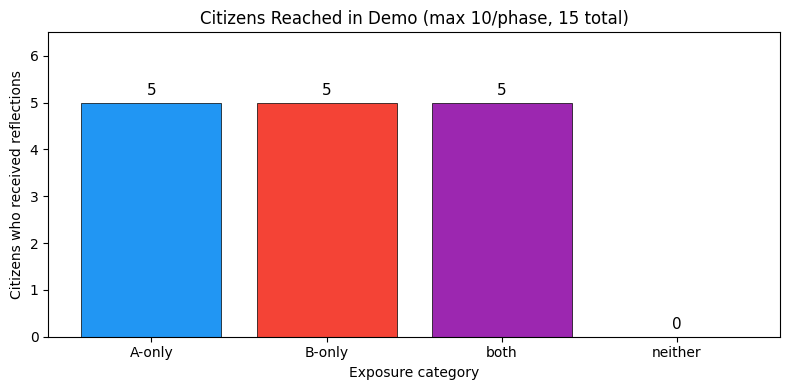

In [9]:
import matplotlib.pyplot as plt

# Among citizens who received reflections, show count by exposure
demo_df = df[df["n_reflections"] > 0]
exposure_order = ["A-only", "B-only", "both", "neither"]
colors = {"A-only": "#2196F3", "B-only": "#F44336", "both": "#9C27B0", "neither": "#9E9E9E"}

counts = demo_df.groupby("exposure")["agent_id"].count().reindex(exposure_order, fill_value=0)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(exposure_order, counts, color=[colors[e] for e in exposure_order], edgecolor="black", linewidth=0.5)

ax.set_ylabel("Citizens who received reflections")
ax.set_xlabel("Exposure category")
ax.set_title(f"Citizens Reached in Demo (max {MAX_DEMO}/phase, {int(counts.sum())} total)")

for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{int(val)}", ha="center", va="bottom", fontsize=11)

ax.set_ylim(0, max(counts) * 1.3 if max(counts) > 0 else 1)
plt.tight_layout()
plt.show()

## 5. Reflection Metadata Structure

Verify the reflection dict structure matches the spec: `{"day", "phase", "text", "messages_received"}`.

In [10]:
# Pick a "both" citizen — they have reflections from both phases
both_citizen = next(c for c in sn.agents_active.values() if c.political_exposure == "both")
print(f"Agent {both_citizen.id} (exposure: {both_citizen.political_exposure})")
print(f"Number of reflections: {len(both_citizen.reflections)}\n")

for i, ref in enumerate(both_citizen.reflections):
    print(f"--- Reflection {i+1} ---")
    print(f"  Day:    {ref['day']}")
    print(f"  Phase:  {ref['phase']}")
    print(f"  Keys:   {set(ref.keys())}")
    print(f"  Messages received: {len(ref['messages_received'])} message(s)")
    print(f"  Text (first 200 chars): {ref['text'][:200]}...")
    print()

Agent 1624.0 (exposure: both)
Number of reflections: 2

--- Reflection 1 ---
  Day:    1
  Phase:  P-A
  Keys:   {'text', 'phase', 'messages_received', 'day'}
  Messages received: 1 message(s)
  Text (first 200 chars): Reading this message makes me reflect on the connection between the climate crisis and the cost-of-living crisis, which resonates with my belief in fairness and equal opportunity for all. The idea tha...

--- Reflection 2 ---
  Day:    1
  Phase:  P-B
  Keys:   {'text', 'phase', 'messages_received', 'day'}
  Messages received: 1 message(s)
  Text (first 200 chars): This message certainly raises some valid concerns about the potential financial impact that a carbon tax could have on working-class families, especially during a cost of living crisis. I can understa...



## 6. Reflection Word Count Distribution

Check that reflection lengths are in the expected ~100–150 word range.

Reflection word count statistics:
       count   mean   std    min    25%    50%    75%    max
phase                                                       
P-A     10.0  174.7  12.4  152.0  167.2  174.5  181.5  194.0
P-B     10.0  193.0  13.9  176.0  180.8  190.5  204.8  212.0


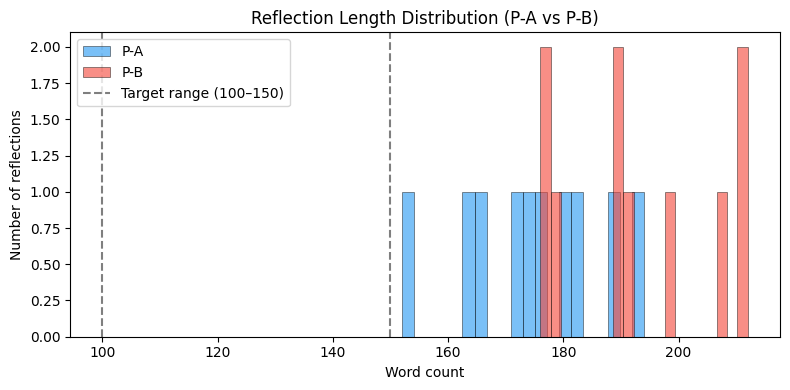

In [11]:
# Collect all reflection word counts
word_counts = []
for citizen in sn.agents_active.values():
    for ref in citizen.reflections:
        wc = len(ref["text"].split())
        word_counts.append({"phase": ref["phase"], "word_count": wc})

wc_df = pd.DataFrame(word_counts)

if not wc_df.empty:
    print("Reflection word count statistics:")
    print(wc_df.groupby("phase")["word_count"].describe().round(1).to_string())

    fig, ax = plt.subplots(figsize=(8, 4))
    for phase, color in [("P-A", "#2196F3"), ("P-B", "#F44336")]:
        subset = wc_df[wc_df["phase"] == phase]["word_count"]
        ax.hist(subset, bins=20, alpha=0.6, label=phase, color=color, edgecolor="black", linewidth=0.5)

    ax.axvline(100, color="black", linestyle="--", alpha=0.5, label="Target range (100–150)")
    ax.axvline(150, color="black", linestyle="--", alpha=0.5)
    ax.set_xlabel("Word count")
    ax.set_ylabel("Number of reflections")
    ax.set_title("Reflection Length Distribution (P-A vs P-B)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No reflections found.")

## 7. Sanity Checks

Verify the acceptance criteria from Issue 6:
1. Only connected citizens received the message
2. Neither-exposure citizens have zero reflections
3. Reflection dicts have the correct structure
4. Political agents each generated exactly one message (same for all citizens)

In [13]:
checks_passed = 0
checks_total = 0

# Identify the demo subsets (citizens who were actually broadcast to)
demo_a = set(id(c) for c in full_a[:MAX_DEMO])  # citizens reached in P-A
demo_b = set(id(c) for c in full_b[:MAX_DEMO])  # citizens reached in P-B

# Check 1: Neither-exposure citizens have 0 reflections
checks_total += 1
neither = [c for c in sn.agents_active.values() if c.political_exposure == "neither"]
neither_with_refs = [c for c in neither if len(c.reflections) > 0]
if len(neither_with_refs) == 0:
    print(f"[PASS] {len(neither)} 'neither' citizens have 0 reflections")
    checks_passed += 1
else:
    print(f"[FAIL] {len(neither_with_refs)} 'neither' citizens unexpectedly have reflections")

# Check 2: A-only demo citizens have exactly 1 P-A reflection; non-demo A-only have 0
checks_total += 1
a_only = [c for c in sn.agents_active.values() if c.political_exposure == "A-only"]
a_only_demo = [c for c in a_only if id(c) in demo_a]
a_only_rest = [c for c in a_only if id(c) not in demo_a]
a_demo_ok = all(len(c.reflections) == 1 and c.reflections[0]["phase"] == "P-A" for c in a_only_demo)
a_rest_ok = all(len(c.reflections) == 0 for c in a_only_rest)
if a_demo_ok and a_rest_ok:
    print(f"[PASS] {len(a_only_demo)} demo A-only have 1 P-A reflection; {len(a_only_rest)} others have 0")
    checks_passed += 1
else:
    print(f"[FAIL] A-only checks failed (demo_ok={a_demo_ok}, rest_ok={a_rest_ok})")

# Check 3: B-only demo citizens have exactly 1 P-B reflection; non-demo B-only have 0
checks_total += 1
b_only = [c for c in sn.agents_active.values() if c.political_exposure == "B-only"]
b_only_demo = [c for c in b_only if id(c) in demo_b]
b_only_rest = [c for c in b_only if id(c) not in demo_b]
b_demo_ok = all(len(c.reflections) == 1 and c.reflections[0]["phase"] == "P-B" for c in b_only_demo)
b_rest_ok = all(len(c.reflections) == 0 for c in b_only_rest)
if b_demo_ok and b_rest_ok:
    print(f"[PASS] {len(b_only_demo)} demo B-only have 1 P-B reflection; {len(b_only_rest)} others have 0")
    checks_passed += 1
else:
    print(f"[FAIL] B-only checks failed (demo_ok={b_demo_ok}, rest_ok={b_rest_ok})")

# Check 4: Both demo citizens have up to 2 reflections depending on demo overlap
checks_total += 1
both = [c for c in sn.agents_active.values() if c.political_exposure == "both"]
both_ok = True
for c in both:
    in_a = id(c) in demo_a
    in_b = id(c) in demo_b
    expected = int(in_a) + int(in_b)
    if len(c.reflections) != expected:
        both_ok = False
        break
    if in_a and not any(r["phase"] == "P-A" for r in c.reflections):
        both_ok = False
        break
    if in_b and not any(r["phase"] == "P-B" for r in c.reflections):
        both_ok = False
        break
both_in_a = sum(1 for c in both if id(c) in demo_a)
both_in_b = sum(1 for c in both if id(c) in demo_b)
if both_ok:
    print(f"[PASS] 'both' citizens correct ({both_in_a} in P-A demo, {both_in_b} in P-B demo)")
    checks_passed += 1
else:
    print(f"[FAIL] Some 'both' citizens have unexpected reflections")

# Check 5: Reflection dict structure
checks_total += 1
expected_keys = {"day", "phase", "text", "messages_received"}
all_refs = [r for c in sn.agents_active.values() for r in c.reflections]
keys_ok = all(set(r.keys()) == expected_keys for r in all_refs)
if keys_ok:
    print(f"[PASS] All {len(all_refs)} reflections have correct dict keys: {expected_keys}")
    checks_passed += 1
else:
    print(f"[FAIL] Some reflections have incorrect keys")

# Check 6: All citizens received the same message per phase
checks_total += 1
pa_messages = set()
pb_messages = set()
for c in sn.agents_active.values():
    for r in c.reflections:
        if r["phase"] == "P-A":
            pa_messages.update(r["messages_received"])
        elif r["phase"] == "P-B":
            pb_messages.update(r["messages_received"])
msg_ok = len(pa_messages) == 1 and len(pb_messages) == 1
if msg_ok:
    print(f"[PASS] One unique message per phase (P-A: 1, P-B: 1)")
    checks_passed += 1
else:
    print(f"[FAIL] Expected 1 unique message per phase, got P-A: {len(pa_messages)}, P-B: {len(pb_messages)}")

print(f"\n{checks_passed}/{checks_total} checks passed")

[PASS] 159 'neither' citizens have 0 reflections
[PASS] 5 demo A-only have 1 P-A reflection; 188 others have 0
[PASS] 5 demo B-only have 1 P-B reflection; 119 others have 0
[PASS] 'both' citizens correct (5 in P-A demo, 5 in P-B demo)
[PASS] All 20 reflections have correct dict keys: {'text', 'phase', 'messages_received', 'day'}
[PASS] One unique message per phase (P-A: 1, P-B: 1)

6/6 checks passed


## 8. LLM Call Summary

Total LLM API calls made during this notebook run: 1 `generate_message` per political agent + 1 `receive_political_message` per connected citizen.

In [14]:
pa_calls = 1 + result_pa["reflections_count"]  # 1 generate_message + N receive_political_message
pb_calls = 1 + result_pb["reflections_count"]
total_calls = pa_calls + pb_calls

print(f"Phase P-A: 1 generate_message + {result_pa['reflections_count']} reflections = {pa_calls} LLM calls")
print(f"Phase P-B: 1 generate_message + {result_pb['reflections_count']} reflections = {pb_calls} LLM calls")
print(f"Total LLM calls for Day 1 broadcast phases: {total_calls}")
print(f"\nFor a {n_total}-citizen population over 30 days with 2 broadcast phases/day:")
print(f"  Estimated broadcast LLM calls: ~{total_calls * 30:,}")

Phase P-A: 1 generate_message + 10 reflections = 11 LLM calls
Phase P-B: 1 generate_message + 10 reflections = 11 LLM calls
Total LLM calls for Day 1 broadcast phases: 22

For a 651-citizen population over 30 days with 2 broadcast phases/day:
  Estimated broadcast LLM calls: ~660
